# KNN Neighbourhood Model — Baseline Prototype

Hybrid neighbourhood model: find content-similar training participants for A,
aggregate their yes/no decisions toward partners similar to B, and rank by
`score_cf(A→B)`.

**Input:** `two_sided_pair_features.csv`  
**CV:** 3-fold wave-based split (no cross-wave leakage)  
**Model:** Non-parametric KNN CF (no training step)

Run all cells top to bottom.

## 1. Imports and Setup

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

DATA_PATH = Path("..") / "data" / "two_sided_pair_features.csv"
K_VALUES = [3, 5]

print(f"Data path: {DATA_PATH.resolve()}")

Data path: C:\SMU_MITB\RecSys\project_2\data\two_sided_pair_features.csv


## 2. Hyperparameter Constants

In [20]:
K_NEIGHBOURS = 10
K_PARTNERS = 10
FALLBACK_SCORE = 0.0

## 3. Load Data

In [21]:
df = pd.read_csv(DATA_PATH)

profile_cols = [c for c in df.columns if c.endswith("_A")]
partner_cols = [c for c in df.columns if c.endswith("_B")]

print(f"Rows: {len(df):,}")
print(f"Waves: {sorted(df['wave'].unique())}")
print(f"Profile features (A-side): {len(profile_cols)}")
print(f"dec=1 rate: {df['dec'].mean():.3f}")
print(f"match=1 rate: {df['match'].mean():.3f}")
df.head()

Rows: 8,210
Waves: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Profile features (A-side): 45
dec=1 rate: 0.420
match=1 rate: 0.164


,iid,pid,wave,dec,match,age_A,amb1_1_A,amb2_1_A,amb3_1_A,art_A,...,shar2_1_B,shopping_B,sinc1_1_B,sinc2_1_B,sinc3_1_B,sports_B,theater_B,tv_B,tvsports_B,yoga_B
0,1,11,1,1,0,21.0,15.0,5.0,7.0,1.0,...,5.0,5.0,20.0,5.0,9.0,8.0,4.0,2.0,7.0,1.0
1,1,12,1,1,0,21.0,15.0,5.0,7.0,1.0,...,0.0,5.0,0.0,15.0,9.0,9.0,4.0,6.0,7.0,5.0
2,1,13,1,1,1,21.0,15.0,5.0,7.0,1.0,...,14.0,8.0,18.0,16.0,7.0,7.0,10.0,8.0,8.0,1.0
3,1,14,1,1,1,21.0,15.0,5.0,7.0,1.0,...,20.0,6.0,5.0,15.0,9.0,10.0,3.0,7.0,6.0,1.0
4,1,15,1,1,1,21.0,15.0,5.0,7.0,1.0,...,10.0,2.0,10.0,20.0,7.0,9.0,9.0,6.0,7.0,1.0


## 4. Cross-Validation Fold Definitions

In [22]:
FOLDS = {
    1: [1, 4, 5, 17, 19, 20, 21],
    2: [3, 6, 7, 11, 13, 15, 18],
    3: [2, 8, 9, 10, 12, 14, 16],
}

all_waves = set(df["wave"].unique())
fold_waves = set(w for waves in FOLDS.values() for w in waves)
assert all_waves == fold_waves, f"Fold waves {fold_waves} != data waves {all_waves}"

for fold_id, waves in FOLDS.items():
    print(f"Fold {fold_id}: waves {waves}")

Fold 1: waves [1, 4, 5, 17, 19, 20, 21]
Fold 2: waves [3, 6, 7, 11, 13, 15, 18]
Fold 3: waves [2, 8, 9, 10, 12, 14, 16]


## 5. Profile Building Functions

In [23]:
def build_train_profiles(train_df):
    """Unified profile table from all training participants (iid and pid)."""
    profiles_from_A = (
        train_df.groupby("iid")[profile_cols]
        .first()
        .rename(columns={c: c.replace("_A", "") for c in profile_cols})
    )
    profiles_from_B = (
        train_df.groupby("pid")[partner_cols]
        .first()
        .rename(columns={c: c.replace("_B", "") for c in partner_cols})
    )
    return profiles_from_B.combine_first(profiles_from_A)


def build_test_profiles(test_df):
    """Unified profile table from all test participants (iid and pid)."""
    test_profiles = (
        test_df.groupby("iid")[profile_cols]
        .first()
        .rename(columns={c: c.replace("_A", "") for c in profile_cols})
    )
    test_partner_profiles = (
        test_df.groupby("pid")[partner_cols]
        .first()
        .rename(columns={c: c.replace("_B", "") for c in partner_cols})
    )
    return test_partner_profiles.combine_first(test_profiles)

## 6. Missing Value Imputation

In [24]:
def impute_profiles(train_profiles, test_profiles_all):
    """Mean-impute using training profile statistics only."""
    feature_cols = train_profiles.columns.tolist()
    imputer = SimpleImputer(strategy="mean")

    train_profiles_imputed = pd.DataFrame(
        imputer.fit_transform(train_profiles),
        index=train_profiles.index,
        columns=feature_cols,
    )
    test_profiles_imputed = pd.DataFrame(
        imputer.transform(test_profiles_all),
        index=test_profiles_all.index,
        columns=feature_cols,
    )
    return train_profiles_imputed, test_profiles_imputed

## 7. Neighbour and Partner Search Functions

In [25]:
def find_neighbours(A_profile, train_profiles_imputed, k):
    """Return top-k training participants most similar to A (cosine similarity)."""
    sims = cosine_similarity(
        A_profile.reshape(1, -1),
        train_profiles_imputed.values,
    )[0]
    top_k_indices = np.argsort(sims)[::-1][:k]
    return [
        (train_profiles_imputed.index[i], sims[i])
        for i in top_k_indices
    ]


def find_similar_partners(B_profile, train_profiles_imputed, k):
    """Return top-k training participants most similar to B (cosine similarity)."""
    sims = cosine_similarity(
        B_profile.reshape(1, -1),
        train_profiles_imputed.values,
    )[0]
    top_k_indices = np.argsort(sims)[::-1][:k]
    return [
        (train_profiles_imputed.index[i], sims[i])
        for i in top_k_indices
    ]

## 8. Decision Lookup Builder

In [26]:
def build_decision_lookup(train_df):
    """Build dict {(iid, pid): dec} for all training interactions."""
    return dict(
        zip(
            zip(train_df["iid"], train_df["pid"]),
            train_df["dec"],
        )
    )

## 9. CF Score Function

In [27]:
def compute_cf_score(
    A_neighbours,
    B_similar_partners,
    train_decision_lookup,
    fallback_score,
):
    """Weighted aggregate of neighbour decisions toward partners similar to B."""
    numerator = 0.0
    denominator = 0.0

    for neighbour_iid, sim_ac in A_neighbours:
        for partner_pid, sim_bb in B_similar_partners:
            dec_val = train_decision_lookup.get((neighbour_iid, partner_pid))
            if dec_val is not None:
                weight = sim_ac * sim_bb
                numerator += weight * dec_val
                denominator += weight

    if denominator == 0:
        return fallback_score

    return numerator / denominator

## 10. Scoring Loop (with tqdm)

In [28]:
def score_test_pairs(
    test_df,
    test_profiles_imputed,
    train_profiles_imputed,
    train_decision_lookup,
    k_neighbours,
    k_partners,
    fallback_score,
):
    """Generate CF scores for every directed pair in the test fold."""
    scores = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Scoring test pairs"):
        iid = row["iid"]
        pid = row["pid"]

        A_profile = test_profiles_imputed.loc[iid].values
        B_profile = test_profiles_imputed.loc[pid].values

        A_neighbours = find_neighbours(
            A_profile, train_profiles_imputed, k_neighbours
        )
        B_similar_partners = find_similar_partners(
            B_profile, train_profiles_imputed, k_partners
        )

        cf_score = compute_cf_score(
            A_neighbours,
            B_similar_partners,
            train_decision_lookup,
            fallback_score,
        )

        scores.append(
            {
                "iid": iid,
                "pid": pid,
                "wave": row["wave"],
                "score_cf": cf_score,
                "match": row["match"],
                "dec": row["dec"],
            }
        )

    return pd.DataFrame(scores)

## 11. Score Distribution Diagnostics

In [29]:
def print_score_diagnostics(scores_df, fallback_score):
    print(f"Score min:     {scores_df['score_cf'].min():.4f}")
    print(f"Score max:     {scores_df['score_cf'].max():.4f}")
    print(f"Score mean:    {scores_df['score_cf'].mean():.4f}")
    print(f"Score std:     {scores_df['score_cf'].std():.4f}")

    fallback_count = (scores_df["score_cf"] == fallback_score).sum()
    print(f"Pairs using fallback score: {fallback_count} / {len(scores_df)}")

    return {
        "min": scores_df["score_cf"].min(),
        "max": scores_df["score_cf"].max(),
        "mean": scores_df["score_cf"].mean(),
        "std": scores_df["score_cf"].std(),
        "fallback_count": fallback_count,
        "total_pairs": len(scores_df),
    }

## 12. Intermediary Evaluation (AUC on dec)

In [30]:
def compute_intermediary_auc(scores_df):
    """Compute AUC on dec; flip scores if AUC < 0.5."""
    scores_df = scores_df.copy()
    auc = roc_auc_score(scores_df["dec"], scores_df["score_cf"])
    flipped = False

    if auc < 0.5:
        print("AUC below 0.5 — flipping scores")
        scores_df["score_cf"] = 1 - scores_df["score_cf"]
        auc = 1 - auc
        flipped = True
        print(f"Flipped AUC: {auc:.4f}")
    else:
        print(f"CF AUC on dec: {auc:.4f}")

    return scores_df, auc, flipped

## 13. Unilateral Ranking

In [31]:
def get_unilateral_ranking(scores_df):
    rankings = {}
    for iid, group in scores_df.groupby("iid"):
        ranked_pids = (
            group.sort_values("score_cf", ascending=False)["pid"].tolist()
        )
        rankings[iid] = ranked_pids
    return rankings

## 14. Reciprocal Re-ranking

In [32]:
def get_reciprocal_ranking(scores_df):
    score_lookup = dict(
        zip(
            zip(scores_df["iid"], scores_df["pid"]),
            scores_df["score_cf"],
        )
    )

    rankings = {}
    for iid, group in scores_df.groupby("iid"):
        mutual_scores = []
        for _, row in group.iterrows():
            pid = row["pid"]
            score_ab = row["score_cf"]
            score_ba = score_lookup.get((pid, iid))

            if score_ba is None:
                print(f"Warning: missing reverse score for ({pid}, {iid})")
                continue

            mutual = np.sqrt(score_ab * score_ba)
            mutual_scores.append((pid, mutual))

        ranked_pids = [
            pid for pid, _ in sorted(mutual_scores, key=lambda x: x[1], reverse=True)
        ]
        rankings[iid] = ranked_pids

    return rankings

## 15. Evaluation Metric Functions

In [33]:
def mutual_match_at_k(ranked_list, matches, k):
    if len(matches) == 0:
        return None
    top_k = ranked_list[:k]
    hits = sum(1 for pid in top_k if pid in matches)
    return hits / min(k, len(matches))


def ndcg_at_k(ranked_list, matches, k):
    if len(matches) == 0:
        return None
    top_k = ranked_list[:k]
    dcg = sum(
        1 / np.log2(i + 2)
        for i, pid in enumerate(top_k)
        if pid in matches
    )
    ideal_hits = min(k, len(matches))
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    if idcg == 0:
        return None
    return dcg / idcg


def evaluate_ranking(rankings, scores_df, k_values=None):
    if k_values is None:
        k_values = K_VALUES

    results = {f"MM@{k}": [] for k in k_values}
    results.update({f"NDCG@{k}": [] for k in k_values})
    excluded = 0
    total = 0

    for iid, ranked_list in rankings.items():
        matches = set(
            scores_df[
                (scores_df["iid"] == iid) & (scores_df["match"] == 1)
            ]["pid"]
        )
        total += 1
        if len(matches) == 0:
            excluded += 1
            continue

        for k in k_values:
            mm = mutual_match_at_k(ranked_list, matches, k)
            ndcg = ndcg_at_k(ranked_list, matches, k)
            if mm is not None:
                results[f"MM@{k}"].append(mm)
            if ndcg is not None:
                results[f"NDCG@{k}"].append(ndcg)

    averages = {key: np.mean(vals) for key, vals in results.items()}
    averages["excluded"] = excluded
    averages["total"] = total
    return averages

## 16. Main Loop — iterate over 3 folds

In [34]:
fold_results = []

for fold_id, test_waves in FOLDS.items():
    print(f"\n{'=' * 60}")
    print(f"FOLD {fold_id} — test waves: {test_waves}")
    print(f"{'=' * 60}")

    train_df = df[~df["wave"].isin(test_waves)].copy()
    test_df = df[df["wave"].isin(test_waves)].copy()

    train_waves = train_df["wave"].unique().tolist()
    assert len(set(train_waves) & set(test_waves)) == 0, \
        "Data leakage: test waves found in training"

    test_pairs = set(zip(test_df["iid"], test_df["pid"]))
    for a, b in test_pairs:
        assert (b, a) in test_pairs, f"Missing reverse pair ({b}, {a})"

    train_profiles = build_train_profiles(train_df)
    test_profiles_all = build_test_profiles(test_df)
    train_profiles_imputed, test_profiles_imputed = impute_profiles(
        train_profiles, test_profiles_all
    )
    train_decision_lookup = build_decision_lookup(train_df)

    print(f"dec=1 rate in train:  {train_df['dec'].mean():.3f}")
    print(f"match=1 rate in test: {test_df['match'].mean():.3f}")
    print(f"Training rows:        {len(train_df)}")
    print(f"Test rows:            {len(test_df)}")
    print(f"Training participants: {train_profiles_imputed.shape[0]}")
    print(f"Test participants:     {test_profiles_imputed.shape[0]}")

    scores_df = score_test_pairs(
        test_df,
        test_profiles_imputed,
        train_profiles_imputed,
        train_decision_lookup,
        K_NEIGHBOURS,
        K_PARTNERS,
        FALLBACK_SCORE,
    )

    score_stats = print_score_diagnostics(scores_df, FALLBACK_SCORE)

    scores_df, auc, flipped = compute_intermediary_auc(scores_df)

    assert scores_df["score_cf"].between(0, 1).all(), "Scores outside [0, 1]"

    uni_rankings = get_unilateral_ranking(scores_df)
    uni_eval = evaluate_ranking(uni_rankings, scores_df)

    rec_rankings = get_reciprocal_ranking(scores_df)
    rec_eval = evaluate_ranking(rec_rankings, scores_df)

    print(
        f"Unilateral  — MM@3: {uni_eval['MM@3']:.3f} | MM@5: {uni_eval['MM@5']:.3f} | "
        f"NDCG@3: {uni_eval['NDCG@3']:.3f} | NDCG@5: {uni_eval['NDCG@5']:.3f} | "
        f"excluded: {uni_eval['excluded']}/{uni_eval['total']}"
    )
    print(
        f"Reciprocal  — MM@3: {rec_eval['MM@3']:.3f} | MM@5: {rec_eval['MM@5']:.3f} | "
        f"NDCG@3: {rec_eval['NDCG@3']:.3f} | NDCG@5: {rec_eval['NDCG@5']:.3f} | "
        f"excluded: {rec_eval['excluded']}/{rec_eval['total']}"
    )

    fold_results.append(
        {
            "fold_id": fold_id,
            "auc": auc,
            "flipped": flipped,
            "score_stats": score_stats,
            "unilateral": uni_eval,
            "reciprocal": rec_eval,
        }
    )


FOLD 1 — test waves: [1, 4, 5, 17, 19, 20, 21]
dec=1 rate in train:  0.416
match=1 rate in test: 0.186
Training rows:        5400
Test rows:            2810
Training participants: 358
Test participants:     186


Scoring test pairs: 100%|██████████| 2810/2810 [00:02<00:00, 1043.21it/s]


Score min:     0.0000
Score max:     1.0000
Score mean:    0.4022
Score std:     0.2857
Pairs using fallback score: 519 / 2810
CF AUC on dec: 0.5266
Unilateral  — MM@3: 0.276 | MM@5: 0.386 | NDCG@3: 0.246 | NDCG@5: 0.305 | excluded: 33/186
Reciprocal  — MM@3: 0.272 | MM@5: 0.397 | NDCG@3: 0.242 | NDCG@5: 0.306 | excluded: 33/186

FOLD 2 — test waves: [3, 6, 7, 11, 13, 15, 18]
dec=1 rate in train:  0.417
match=1 rate in test: 0.160
Training rows:        5720
Test rows:            2490
Training participants: 377
Test participants:     167


Scoring test pairs: 100%|██████████| 2490/2490 [00:02<00:00, 1216.35it/s]


Score min:     0.0000
Score max:     1.0000
Score mean:    0.4519
Score std:     0.2777
Pairs using fallback score: 371 / 2490
CF AUC on dec: 0.5241
Unilateral  — MM@3: 0.322 | MM@5: 0.420 | NDCG@3: 0.264 | NDCG@5: 0.310 | excluded: 33/167
Reciprocal  — MM@3: 0.261 | MM@5: 0.369 | NDCG@3: 0.224 | NDCG@5: 0.270 | excluded: 33/167

FOLD 3 — test waves: [2, 8, 9, 10, 12, 14, 16]
dec=1 rate in train:  0.427
match=1 rate in test: 0.148
Training rows:        5300
Test rows:            2910
Training participants: 353
Test participants:     191


Scoring test pairs: 100%|██████████| 2910/2910 [00:02<00:00, 1156.49it/s]


Score min:     0.0000
Score max:     1.0000
Score mean:    0.4193
Score std:     0.2648
Pairs using fallback score: 404 / 2910
CF AUC on dec: 0.5485
Unilateral  — MM@3: 0.217 | MM@5: 0.367 | NDCG@3: 0.191 | NDCG@5: 0.265 | excluded: 36/191
Reciprocal  — MM@3: 0.247 | MM@5: 0.368 | NDCG@3: 0.213 | NDCG@5: 0.272 | excluded: 36/191


## 17. Aggregate and Print Final Results Table

In [35]:
def mean_fold_metric(fold_results, condition, key):
    return np.mean([fold[condition][key] for fold in fold_results])


avg_score_stats = {
    key: np.mean([fold["score_stats"][key] for fold in fold_results])
    for key in ["min", "max", "mean", "std"]
}
avg_fallback = np.mean([fold["score_stats"]["fallback_count"] for fold in fold_results])
avg_total_pairs = np.mean([fold["score_stats"]["total_pairs"] for fold in fold_results])
fallback_pct = 100 * avg_fallback / avg_total_pairs

print("\n=== Hyperparameters ===")
print(f"K_NEIGHBOURS:   {K_NEIGHBOURS}")
print(f"K_PARTNERS:     {K_PARTNERS}")
print(f"FALLBACK_SCORE: {FALLBACK_SCORE}")

print("\n=== Score Distribution (average across folds) ===")
print(f"Min:  {avg_score_stats['min']:.4f}")
print(f"Max:  {avg_score_stats['max']:.4f}")
print(f"Mean: {avg_score_stats['mean']:.4f}")
print(f"Std:  {avg_score_stats['std']:.4f}")
print(
    f"Pairs using fallback score: {avg_fallback:.0f} / {avg_total_pairs:.0f} "
    f"({fallback_pct:.1f}%)"
)

print("\n=== Intermediary Metric (predicting dec) ===")
print(f"KNN CF    AUC: {np.mean([fold['auc'] for fold in fold_results]):.3f}")

print("\n=== Final System Metrics (predicting match) ===")
avg_excluded = np.mean([fold["unilateral"]["excluded"] for fold in fold_results])
avg_total = np.mean([fold["unilateral"]["total"] for fold in fold_results])
print(f"Participants with zero matches excluded: {avg_excluded:.0f} of {avg_total:.0f} per fold (average)")
print()
print(
    f"{'Model':<10} {'Condition':<12} {'MM@3':>8} {'MM@5':>8} "
    f"{'NDCG@3':>8} {'NDCG@5':>8}"
)
for condition in ["unilateral", "reciprocal"]:
    print(
        f"{'KNN CF':<10} {condition.capitalize():<12} "
        f"{mean_fold_metric(fold_results, condition, 'MM@3'):>8.3f} "
        f"{mean_fold_metric(fold_results, condition, 'MM@5'):>8.3f} "
        f"{mean_fold_metric(fold_results, condition, 'NDCG@3'):>8.3f} "
        f"{mean_fold_metric(fold_results, condition, 'NDCG@5'):>8.3f}"
    )

print("\n=== Per-Fold Breakdown ===")
for fold in fold_results:
    fold_id = fold["fold_id"]
    stats = fold["score_stats"]
    print(f"\nFold {fold_id}:")
    print(
        f"  Scores — min={stats['min']:.4f} max={stats['max']:.4f} "
        f"mean={stats['mean']:.4f} std={stats['std']:.4f} "
        f"fallback={stats['fallback_count']}/{stats['total_pairs']}"
    )
    print(f"  AUC on dec: {fold['auc']:.3f}" + (" (flipped)" if fold["flipped"] else ""))
    uni = fold["unilateral"]
    rec = fold["reciprocal"]
    print(
        f"  Unilateral  — MM@3={uni['MM@3']:.3f} MM@5={uni['MM@5']:.3f} "
        f"NDCG@3={uni['NDCG@3']:.3f} NDCG@5={uni['NDCG@5']:.3f} "
        f"(excluded {uni['excluded']}/{uni['total']})"
    )
    print(
        f"  Reciprocal  — MM@3={rec['MM@3']:.3f} MM@5={rec['MM@5']:.3f} "
        f"NDCG@3={rec['NDCG@3']:.3f} NDCG@5={rec['NDCG@5']:.3f} "
        f"(excluded {rec['excluded']}/{rec['total']})"
    )


=== Hyperparameters ===
K_NEIGHBOURS:   10
K_PARTNERS:     10
FALLBACK_SCORE: 0.0

=== Score Distribution (average across folds) ===
Min:  0.0000
Max:  1.0000
Mean: 0.4245
Std:  0.2761
Pairs using fallback score: 431 / 2737 (15.8%)

=== Intermediary Metric (predicting dec) ===
KNN CF    AUC: 0.533

=== Final System Metrics (predicting match) ===
Participants with zero matches excluded: 34 of 181 per fold (average)

Model      Condition        MM@3     MM@5   NDCG@3   NDCG@5
KNN CF     Unilateral      0.272    0.391    0.234    0.293
KNN CF     Reciprocal      0.260    0.378    0.226    0.283

=== Per-Fold Breakdown ===

Fold 1:
  Scores — min=0.0000 max=1.0000 mean=0.4022 std=0.2857 fallback=519/2810
  AUC on dec: 0.527
  Unilateral  — MM@3=0.276 MM@5=0.386 NDCG@3=0.246 NDCG@5=0.305 (excluded 33/186)
  Reciprocal  — MM@3=0.272 MM@5=0.397 NDCG@3=0.242 NDCG@5=0.306 (excluded 33/186)

Fold 2:
  Scores — min=0.0000 max=1.0000 mean=0.4519 std=0.2777 fallback=371/2490
  AUC on dec: 0.524
  

## 18. Grid Search — Hyperparameter Tuning

Search over `K_NEIGHBOURS`, `K_PARTNERS`, and `FALLBACK_SCORE`.
Similarities are precomputed once per fold so varying K is just an index slice — no redundant cosine_similarity calls.

In [36]:
def precompute_similarities(test_profiles_imputed, train_profiles_imputed):
    """Compute test→train cosine similarity matrix once; return lookup structures."""
    sim_matrix = cosine_similarity(
        test_profiles_imputed.values, train_profiles_imputed.values
    )
    return {
        "sim_matrix": sim_matrix,
        "sorted_indices": np.argsort(-sim_matrix, axis=1),
        "test_id_to_row": {pid: i for i, pid in enumerate(test_profiles_imputed.index)},
        "train_ids": np.array(train_profiles_imputed.index),
    }


def score_test_pairs_fast(
    test_df, sim_data, train_decision_lookup, k_neighbours, k_partners, fallback_score
):
    """Score all test pairs by slicing precomputed similarity matrix."""
    sim_matrix = sim_data["sim_matrix"]
    sorted_indices = sim_data["sorted_indices"]
    test_id_to_row = sim_data["test_id_to_row"]
    train_ids = sim_data["train_ids"]

    scores = []
    for _, row in test_df.iterrows():
        iid, pid = row["iid"], row["pid"]
        row_A, row_B = test_id_to_row[iid], test_id_to_row[pid]

        top_A = sorted_indices[row_A, :k_neighbours]
        A_neighbours = [(train_ids[i], sim_matrix[row_A, i]) for i in top_A]

        top_B = sorted_indices[row_B, :k_partners]
        B_similar_partners = [(train_ids[i], sim_matrix[row_B, i]) for i in top_B]

        scores.append({
            "iid": iid,
            "pid": pid,
            "wave": row["wave"],
            "score_cf": compute_cf_score(
                A_neighbours, B_similar_partners, train_decision_lookup, fallback_score
            ),
            "match": row["match"],
            "dec": row["dec"],
        })

    return pd.DataFrame(scores)

In [37]:
print("Precomputing fold similarity matrices...")
grid_fold_data = []

for fold_id, test_waves in FOLDS.items():
    train_df = df[~df["wave"].isin(test_waves)].copy()
    test_df = df[df["wave"].isin(test_waves)].copy()

    train_profiles = build_train_profiles(train_df)
    test_profiles_all = build_test_profiles(test_df)
    train_profiles_imputed, test_profiles_imputed = impute_profiles(
        train_profiles, test_profiles_all
    )
    train_decision_lookup = build_decision_lookup(train_df)
    sim_data = precompute_similarities(test_profiles_imputed, train_profiles_imputed)

    grid_fold_data.append({
        "fold_id": fold_id,
        "test_df": test_df,
        "train_decision_lookup": train_decision_lookup,
        "sim_data": sim_data,
    })
    print(f"  Fold {fold_id}: sim matrix {sim_data['sim_matrix'].shape}")

print("Done.")

Precomputing fold similarity matrices...
  Fold 1: sim matrix (186, 358)
  Fold 2: sim matrix (167, 377)
  Fold 3: sim matrix (191, 353)
Done.


In [40]:
from itertools import product

KN_GRID = [5, 10, 20, 30]
KP_GRID = [5, 10, 20, 30]
FB_GRID = [0.0, 0.5]

combos = list(product(KN_GRID, KP_GRID, FB_GRID))
grid_results = []

for kn, kp, fb in tqdm(combos, desc="Grid search"):
    fold_metrics = {"MM@3": [], "MM@5": [], "NDCG@3": [], "NDCG@5": []}

    for fd in grid_fold_data:
        scores_df = score_test_pairs_fast(
            fd["test_df"], fd["sim_data"], fd["train_decision_lookup"], kn, kp, fb
        )
        auc = roc_auc_score(scores_df["dec"], scores_df["score_cf"])
        if auc < 0.5:
            scores_df["score_cf"] = 1 - scores_df["score_cf"]

        rec_rankings = get_reciprocal_ranking(scores_df)
        rec_eval = evaluate_ranking(rec_rankings, scores_df)
        for metric in fold_metrics:
            fold_metrics[metric].append(rec_eval[metric])

    grid_results.append({
        "K_NEIGHBOURS": kn,
        "K_PARTNERS": kp,
        "FALLBACK_SCORE": fb,
        **{m: np.mean(vals) for m, vals in fold_metrics.items()},
    })

grid_df = (
    pd.DataFrame(grid_results)
    .sort_values("NDCG@5", ascending=False)
    .reset_index(drop=True)
)

print(grid_df.to_string(index=False))

best = grid_df.iloc[0]
print(f"\nBest config:")
print(f"  K_NEIGHBOURS={int(best.K_NEIGHBOURS)}  K_PARTNERS={int(best.K_PARTNERS)}  FALLBACK_SCORE={best.FALLBACK_SCORE}")
print(f" MM@3={best['MM@3']:.4f}  MM@5={best['MM@5']:.4f}  NDCG@3={best['NDCG@3']:.4f} NDCG@5={best['NDCG@5']:.4f}  ")

Grid search: 100%|██████████| 32/32 [00:23<00:00,  1.34it/s]

 K_NEIGHBOURS  K_PARTNERS  FALLBACK_SCORE     MM@3     MM@5   NDCG@3   NDCG@5
           20           5             0.0 0.300477 0.427492 0.285316 0.342593
           20          30             0.5 0.300751 0.429992 0.276435 0.337664
           20          30             0.0 0.297120 0.427377 0.272479 0.334551
           20           5             0.5 0.294281 0.405348 0.276269 0.326429
           10          30             0.5 0.288165 0.404556 0.269914 0.325890
           10          30             0.0 0.286972 0.403623 0.268734 0.324938
           30           5             0.0 0.299812 0.412189 0.270696 0.322518
            5          30             0.0 0.290137 0.413062 0.262982 0.321665
           30          30             0.5 0.290456 0.410235 0.262874 0.320230
           30          30             0.0 0.290456 0.410235 0.262874 0.320230
            5           5             0.0 0.283433 0.415056 0.257680 0.318111
           20          20             0.0 0.293870 0.413671 0.25

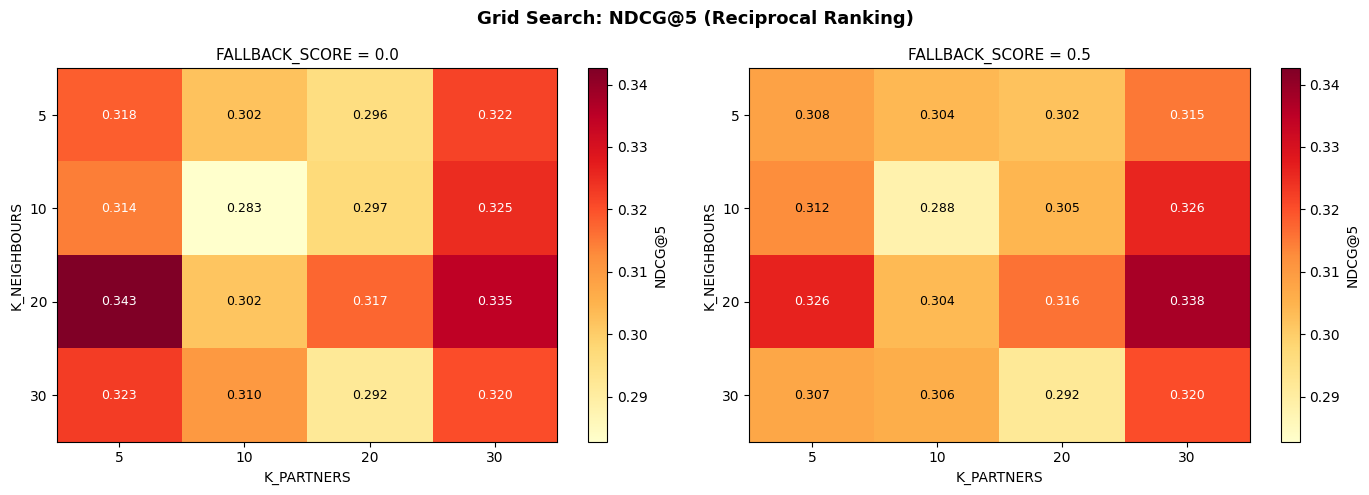

In [39]:
import matplotlib.pyplot as plt

vmin, vmax = grid_df["NDCG@5"].min(), grid_df["NDCG@5"].max()
fig, axes = plt.subplots(1, len(FB_GRID), figsize=(7 * len(FB_GRID), 5))
fig.suptitle("Grid Search: NDCG@5 (Reciprocal Ranking)", fontsize=13, fontweight="bold")

for ax, fb in zip(axes, FB_GRID):
    subset = grid_df[grid_df["FALLBACK_SCORE"] == fb]
    pivot = (
        subset.pivot(index="K_NEIGHBOURS", columns="K_PARTNERS", values="NDCG@5")
        .loc[sorted(KN_GRID), sorted(KP_GRID)]
    )

    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(KP_GRID)))
    ax.set_yticks(range(len(KN_GRID)))
    ax.set_xticklabels(KP_GRID)
    ax.set_yticklabels(KN_GRID)
    ax.set_xlabel("K_PARTNERS", fontsize=10)
    ax.set_ylabel("K_NEIGHBOURS", fontsize=10)
    ax.set_title(f"FALLBACK_SCORE = {fb}", fontsize=11)
    plt.colorbar(im, ax=ax, label="NDCG@5")

    midpoint = (vmin + vmax) / 2
    for i in range(len(KN_GRID)):
        for j in range(len(KP_GRID)):
            val = pivot.values[i, j]
            ax.text(
                j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                color="white" if val > midpoint else "black",
            )

plt.tight_layout()
plt.show()